In [1]:
#CELL 1: Imports and plot style
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'grid.linestyle'    : '--',
    'figure.dpi'        : 150,
    'savefig.bbox'      : 'tight',
    'savefig.facecolor' : 'white',
})

NAVY   = '#0D1B4B'
BLUE   = '#1A3A8F'
ACCENT = '#4A9FD4'
RED    = '#C0392B'
GREEN  = '#27AE60'
GRAY   = '#7F8C8D'
ORANGE = '#E67E22'


In [2]:
# CELL 2: Load and clean generation mix data
# Source: https://nationalgrideso.com/data-portal/historic-generation-mix
# Place df_fuel_ckan.csv in the same folder as this notebook

df = pd.read_csv(r'C:\Users\kshit\ElectricityGrid\df_fuel_ckan.csv', 
                 parse_dates=['DATETIME'])

# Filter to 2021-2026
df = df[(df['DATETIME'].dt.year >= 2021) & (df['DATETIME'].dt.year <= 2026)].copy()
df['DATE']  = df['DATETIME'].dt.date
df['YEAR']  = df['DATETIME'].dt.year
df['MONTH'] = df['DATETIME'].dt.to_period('M')

print(f"Rows loaded: {len(df):,}")
print(f"Date range: {df['DATETIME'].min().date()} to {df['DATETIME'].max().date()}")

Rows loaded: 92,915
Date range: 2021-01-01 to 2026-04-20


In [3]:
# CELL 3: Daily and annual aggregation

daily = df.groupby('DATE').agg(
    gas_mw        = ('GAS',              'mean'),
    wind_mw       = ('WIND',             'mean'),
    solar_mw      = ('SOLAR',            'mean'),
    renewable_pct = ('RENEWABLE_perc',   'mean'),
    carbon_int    = ('CARBON_INTENSITY', 'mean'),
    generation_mw = ('GENERATION',       'mean'),
).reset_index()

daily['DATE'] = pd.to_datetime(daily['DATE'])
daily['YEAR'] = daily['DATE'].dt.year

annual_gen = daily.groupby('YEAR').agg(
    avg_renewable_pct = ('renewable_pct', 'mean'),
    avg_gas_mw        = ('gas_mw',        'mean'),
    avg_carbon_int    = ('carbon_int',    'mean'),
    avg_wind_mw       = ('wind_mw',       'mean'),
).reset_index()

monthly_gen = df.groupby('MONTH').agg(
    carbon_int    = ('CARBON_INTENSITY', 'mean'),
    renewable_pct = ('RENEWABLE_perc',   'mean'),
).reset_index()
monthly_gen['MONTH_DT'] = monthly_gen['MONTH'].dt.to_timestamp()

print("Annual generation summary:")
print(annual_gen.round(1).to_string(index=False))

Annual generation summary:
 YEAR  avg_renewable_pct  avg_gas_mw  avg_carbon_int  avg_wind_mw
 2021               27.5     12245.8           183.3       5590.7
 2022               32.9     12699.6           181.1       7043.9
 2023               35.2      9898.3           149.0       7240.2
 2024               36.0      8267.1           124.0       7480.7
 2025               37.4      8824.9           126.9       7848.4
 2026               41.8      9541.5           134.1      10544.4


In [4]:
# CELL 4: OLS regression: gas dispatch vs renewable share

x = daily['renewable_pct'].values
y = daily['gas_mw'].values

slope, intercept, r, p, se = stats.linregress(x, y)
r2 = r**2

print(f"Slope     : {slope:.1f} MW per 1pct renewable share")
print(f"Intercept : {intercept:.0f} MW")
print(f"R2        : {r2:.3f}")
print(f"p-value   : {p:.2e}")

Slope     : -268.1 MW per 1pct renewable share
Intercept : 19521 MW
R2        : 0.595
p-value   : 0.00e+00


In [5]:
# CELL 5: Load and clean BOA curtailment data
# Source: https://www.neso.energy, search Wind BOA Volumes

BASE = r'C:\Users\kshit\ElectricityGrid' 

boa_files = {
    '2021_22' : BASE + r'\boa_data_2021_22.csv',
    '2022_23' : BASE + r'\boa_data_2022_23.csv',
    '2023_24' : BASE + r'\boa_data_2023_24.csv',
    '2024_25' : BASE + r'\boa_data_2024_25.csv',
    '2025_26' : BASE + r'\boa_data_2025_26.csv',
}

boa = pd.concat(
    [pd.read_csv(p, parse_dates=['Date']).assign(file_year=k)
     for k, p in boa_files.items()],
    ignore_index=True
)

boa['curtailed_mwh'] = boa['BOA_Volume'].abs()
boa['YEAR']  = boa['Date'].dt.year
boa['MONTH'] = boa['Date'].dt.to_period('M')

print(f"BOA rows loaded: {len(boa):,}")
print(f"Date range: {boa['Date'].min().date()} to {boa['Date'].max().date()}")

BOA rows loaded: 897,783
Date range: 2021-04-01 to 2026-03-29


In [6]:
# CELL 6: Annual and monthly curtailment aggregation

annual_curt = (
    boa[boa['YEAR'] <= 2025]
    .groupby('YEAR')
    .agg(
        curtailed_gwh = ('curtailed_mwh', lambda x: x.sum() / 1000),
        n_events      = ('curtailed_mwh', 'count'),
        n_farms       = ('Generator_Name', 'nunique'),
    )
    .reset_index()
)

monthly_curt = (
    boa[boa['YEAR'] <= 2025]
    .groupby('MONTH')
    .agg(curtailed_gwh=('curtailed_mwh', lambda x: x.sum() / 1000))
    .reset_index()
)
monthly_curt['MONTH_DT'] = monthly_curt['MONTH'].dt.to_timestamp()

top_farms = (
    boa[boa['YEAR'] <= 2025]
    .groupby('Generator_Full_Name')
    .agg(total_gwh=('curtailed_mwh', lambda x: x.sum() / 1000))
    .sort_values('total_gwh', ascending=False)
    .head(10)
    .reset_index()
)

print("Annual curtailment summary:")
print(annual_curt.round(1).to_string(index=False))

Annual curtailment summary:
 YEAR  curtailed_gwh  n_events  n_farms
 2021         3082.7     52478      122
 2022         7697.3    119735      142
 2023         8596.1    151541      171
 2024        16669.5    233908      176
 2025        20451.7    263743      174


In [7]:
# CELL 7: Carbon counterfactual
# Method: curtailed MWh x CCGT emission factor (0.4 tCO2/MWh) x UK ETS price

# BEIS 2025 GHG Conversion Factors, Table 8
# Average grid electricity consumed (kgCO2e/kWh), converted to tCO2/MWh
# These are average grid factors — conservative lower bound for curtailment analysis
# True marginal CCGT factor would be higher (~0.35-0.40)
EMISSION_FACTOR = {
    2021: 0.2071,
    2022: 0.2071,
    2023: 0.1770,
    2024: 0.1770,
    2025: 0.1770,
}
carbon_price    = {2021: 47.96, 2022: 52.56, 2023: 45, 2024: 37.18, 2025: 41.84}

cf = pd.DataFrame([{
    'Year'                : int(row['YEAR']),
    'Curtailment (GWh)'   : round(row['curtailed_gwh'], 0),
    'CO2 avoided (Mt)'    : round(row['curtailed_gwh'] * 1000 
                            * EMISSION_FACTOR.get(int(row['YEAR']), 0.1770) 
                            / 1e6, 3),
    'Carbon cost (£M)'    : round(row['curtailed_gwh'] * 1000 
                            * EMISSION_FACTOR.get(int(row['YEAR']), 0.1770)
                            * carbon_price.get(int(row['YEAR']), 40) 
                            / 1e6, 1),
    'Carbon price (£/t)'  : carbon_price.get(int(row['YEAR']), 40),
    'Emission factor'     : EMISSION_FACTOR.get(int(row['YEAR']), 0.1770),
} for _, row in annual_curt.iterrows()])

print("Carbon counterfactual:")
print(cf.to_string(index=False))
print(f"\nTotal curtailment : {cf['Curtailment (GWh)'].sum():,.0f} GWh")
print(f"Total carbon cost : £{cf['Carbon cost (£M)'].sum():,.0f}M")

Carbon counterfactual:
 Year  Curtailment (GWh)  CO2 avoided (Mt)  Carbon cost (£M)  Carbon price (£/t)  Emission factor
 2021             3083.0             0.638              30.6               47.96           0.2071
 2022             7697.0             1.594              83.8               52.56           0.2071
 2023             8596.0             1.522              68.5               45.00           0.1770
 2024            16670.0             2.951             109.7               37.18           0.1770
 2025            20452.0             3.620             151.5               41.84           0.1770

Total curtailment : 56,498 GWh
Total carbon cost : £444M


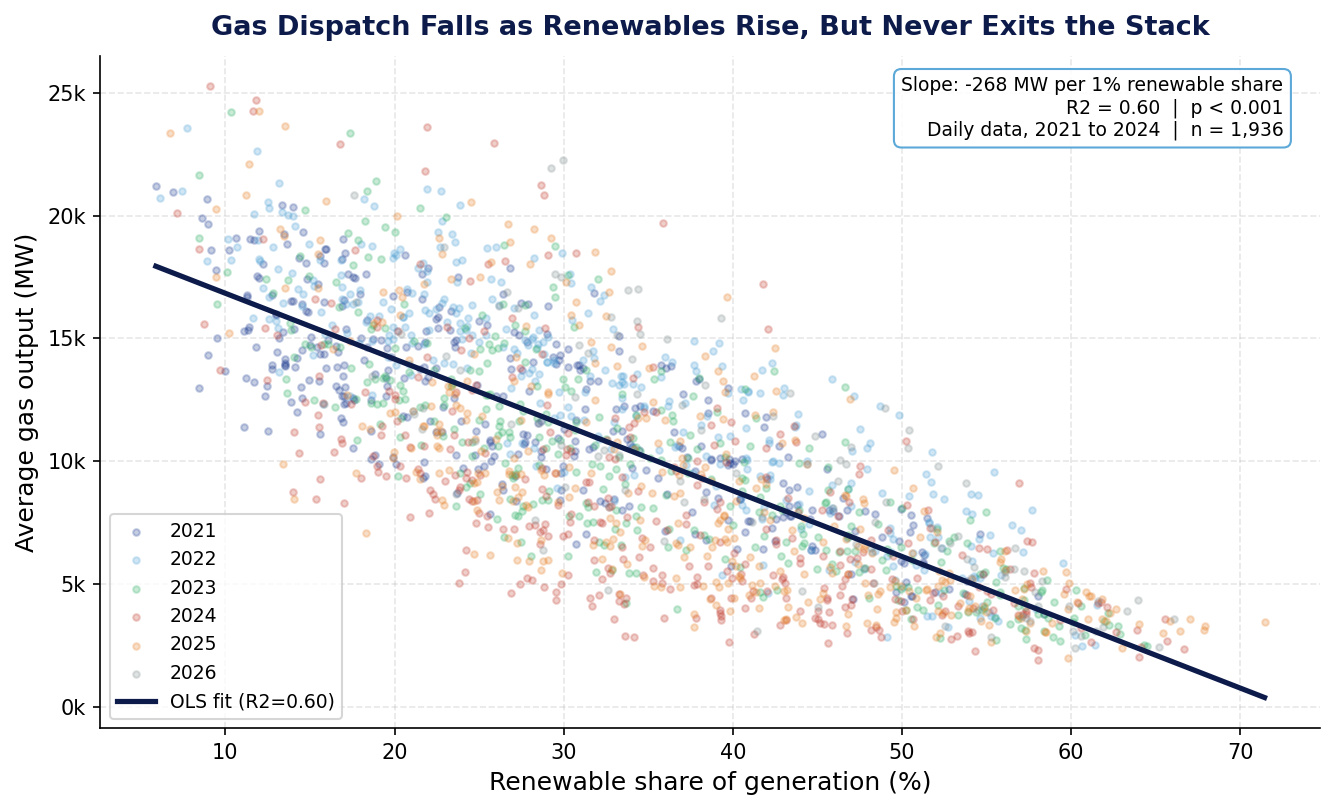

In [8]:
# CELL 8: Figure 1 - Gas dispatch vs renewable share

fig, ax = plt.subplots(figsize=(9, 5.5))

colours = {2021: BLUE, 2022: ACCENT, 2023: GREEN, 2024: RED, 2025: ORANGE, 2026: GRAY}
for yr in sorted(daily['YEAR'].unique()):
    mask = daily['YEAR'] == yr
    ax.scatter(daily.loc[mask, 'renewable_pct'], daily.loc[mask, 'gas_mw'],
               alpha=0.25, s=10, color=colours[yr], label=str(yr), zorder=2)

color=colours.get(int(yr), GRAY)
xline = np.linspace(x.min(), x.max(), 200)
ax.plot(xline, slope * xline + intercept,
        color=NAVY, lw=2.5, zorder=5, label=f'OLS fit (R2={r2:.2f})')

ax.set_xlabel('Renewable share of generation (%)', fontsize=12)
ax.set_ylabel('Average gas output (MW)', fontsize=12)
ax.set_title('Gas Dispatch Falls as Renewables Rise, But Never Exits the Stack',
             fontsize=13, fontweight='bold', color=NAVY, pad=10)

# Stats box top right, legend bottom left
ax.text(0.97, 0.97,
        f'Slope: {slope:.0f} MW per 1% renewable share\n'
        f'R2 = {r2:.2f}  |  p < 0.001\n'
        f'Daily data, 2021 to 2024  |  n = {len(daily):,}',
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=ACCENT, alpha=0.9))

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
ax.legend(fontsize=9, framealpha=0.8, loc='lower left')

plt.tight_layout()
plt.savefig('fig1_gas_vs_renewables.png')
plt.show()

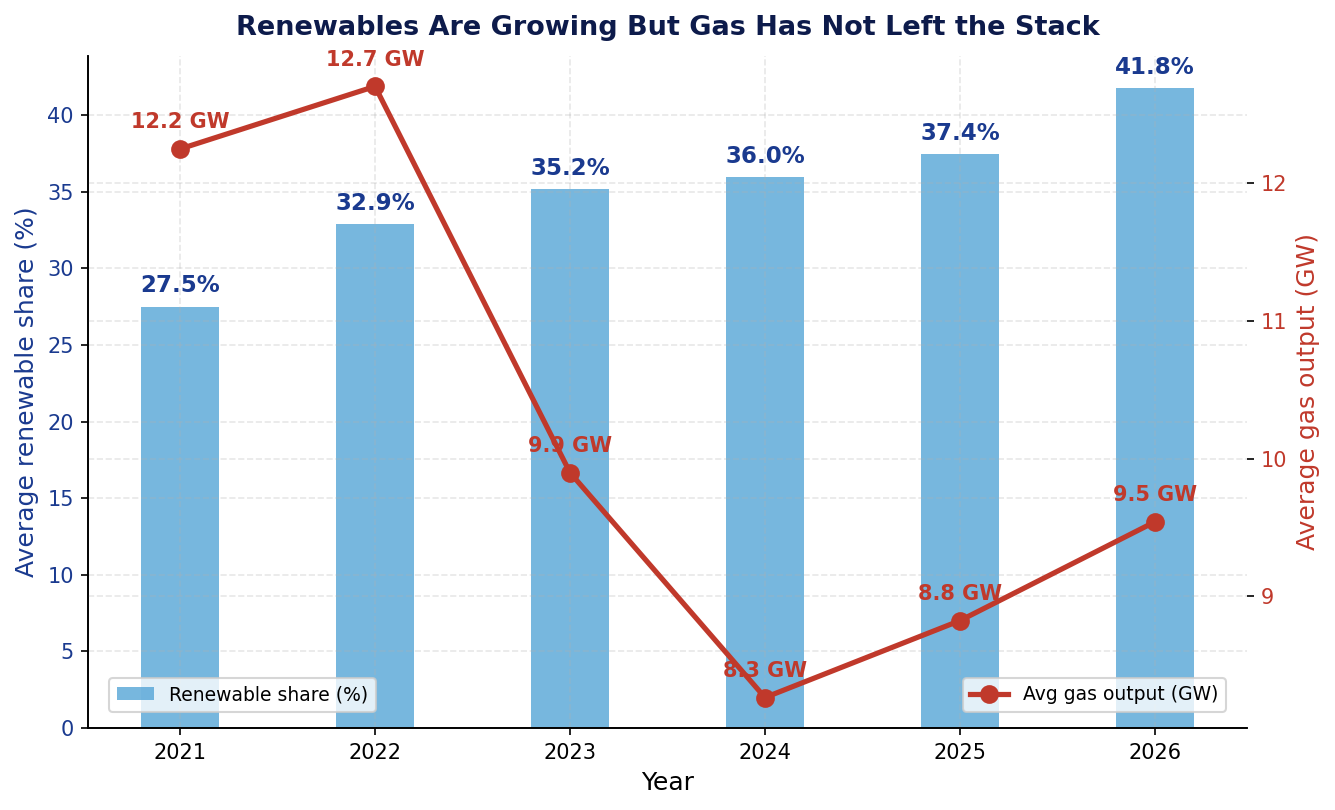

In [9]:
# CELL 9: Figure 2 - Annual renewable share vs gas output

fig, ax1 = plt.subplots(figsize=(9, 5.5))
ax2 = ax1.twinx()

bar_width = 0.4
bars = ax1.bar(annual_gen['YEAR'], annual_gen['avg_renewable_pct'],
               color=ACCENT, alpha=0.75, width=bar_width)
line, = ax2.plot(annual_gen['YEAR'], annual_gen['avg_gas_mw'] / 1000,
                 color=RED, lw=2.5, marker='o', ms=8, zorder=5)

# Renewable pct labels above bars, bold and centred
for bar, val in zip(bars, annual_gen['avg_renewable_pct']):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.6,
             f'{val:.1f}%',
             ha='center', va='bottom',
             fontsize=11, fontweight='bold', color=BLUE)

# Gas labels above markers, bold and centred
for yr, gas in zip(annual_gen['YEAR'], annual_gen['avg_gas_mw']):
    ax2.text(yr, gas / 1000 + 0.12,
             f'{gas/1000:.1f} GW',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold', color=RED)

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Average renewable share (%)', fontsize=12, color=BLUE)
ax2.set_ylabel('Average gas output (GW)', fontsize=12, color=RED)
ax1.set_title('Renewables Are Growing But Gas Has Not Left the Stack',
              fontsize=13, fontweight='bold', color=NAVY, pad=10)

ax1.tick_params(axis='y', labelcolor=BLUE)
ax2.tick_params(axis='y', labelcolor=RED)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Separate legends at bottom of each axis
ax1.legend([bars], ['Renewable share (%)'],
           fontsize=9, framealpha=0.8, loc='lower left',
           bbox_to_anchor=(0.01, 0.01))
ax2.legend([line], ['Avg gas output (GW)'],
           fontsize=9, framealpha=0.8, loc='lower right',
           bbox_to_anchor=(0.99, 0.01))

plt.tight_layout()
plt.savefig('fig2_annual_trend.png')
plt.show()

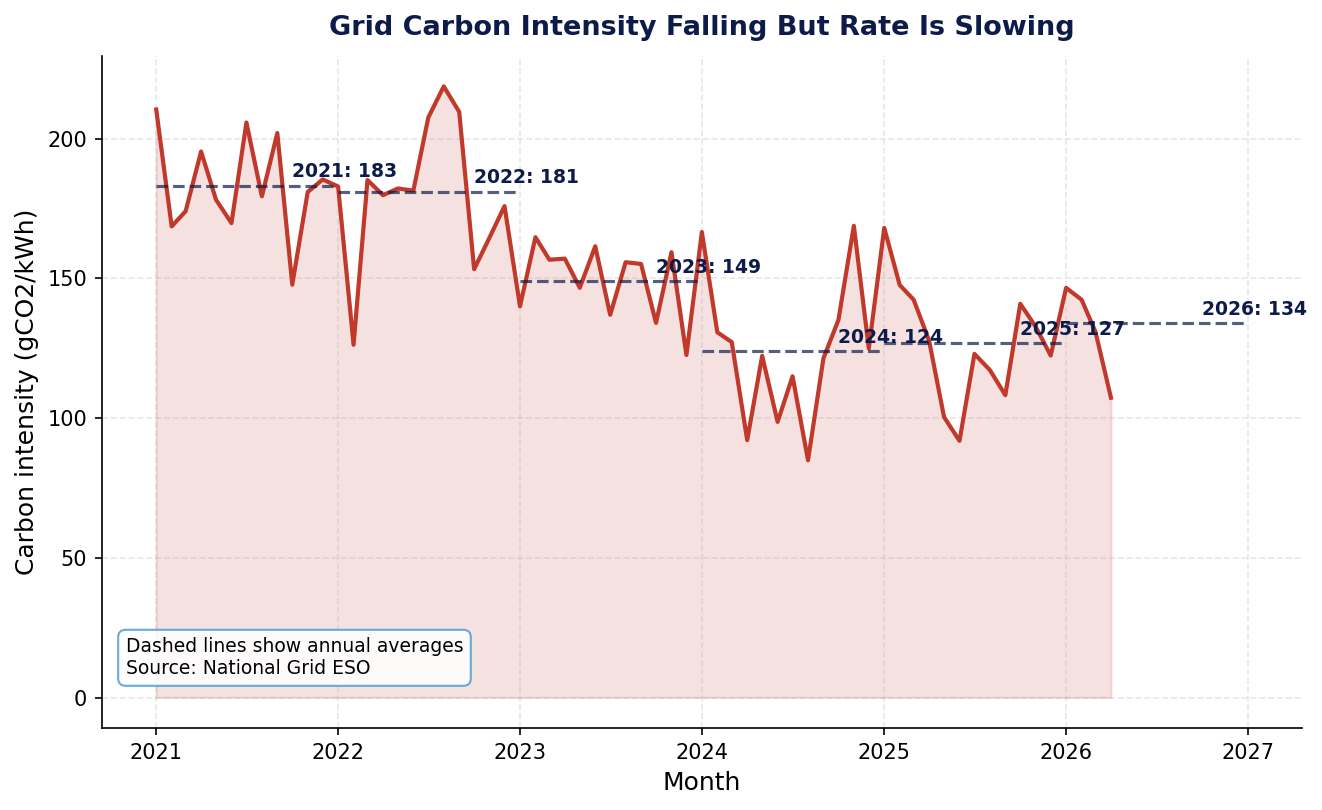

In [10]:
# CELL 10: Figure 3 - Monthly carbon intensity

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.fill_between(monthly_gen['MONTH_DT'], monthly_gen['carbon_int'],
                alpha=0.15, color=RED)
ax.plot(monthly_gen['MONTH_DT'], monthly_gen['carbon_int'],
        color=RED, lw=2)

for yr in annual_gen['YEAR']:
    val   = annual_gen.loc[annual_gen['YEAR'] == yr, 'avg_carbon_int'].values[0]
    start = pd.Timestamp(f'{yr}-01-01')
    end   = pd.Timestamp(f'{yr}-12-31')
    ax.hlines(val, start, end, colors=NAVY, lw=1.5, linestyles='dashed', alpha=0.7)
    ax.text(pd.Timestamp(f'{yr}-10-01'), val + 3,
            f'{yr}: {val:.0f}', fontsize=9, color=NAVY, fontweight='bold')

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Carbon intensity (gCO2/kWh)', fontsize=12)
ax.set_title('Grid Carbon Intensity Falling But Rate Is Slowing',
             fontsize=13, fontweight='bold', color=NAVY, pad=10)

ax.text(0.02, 0.08,
        'Dashed lines show annual averages\nSource: National Grid ESO',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=ACCENT, alpha=0.85))

plt.tight_layout()
plt.savefig('fig3_carbon_intensity.png')
plt.show()

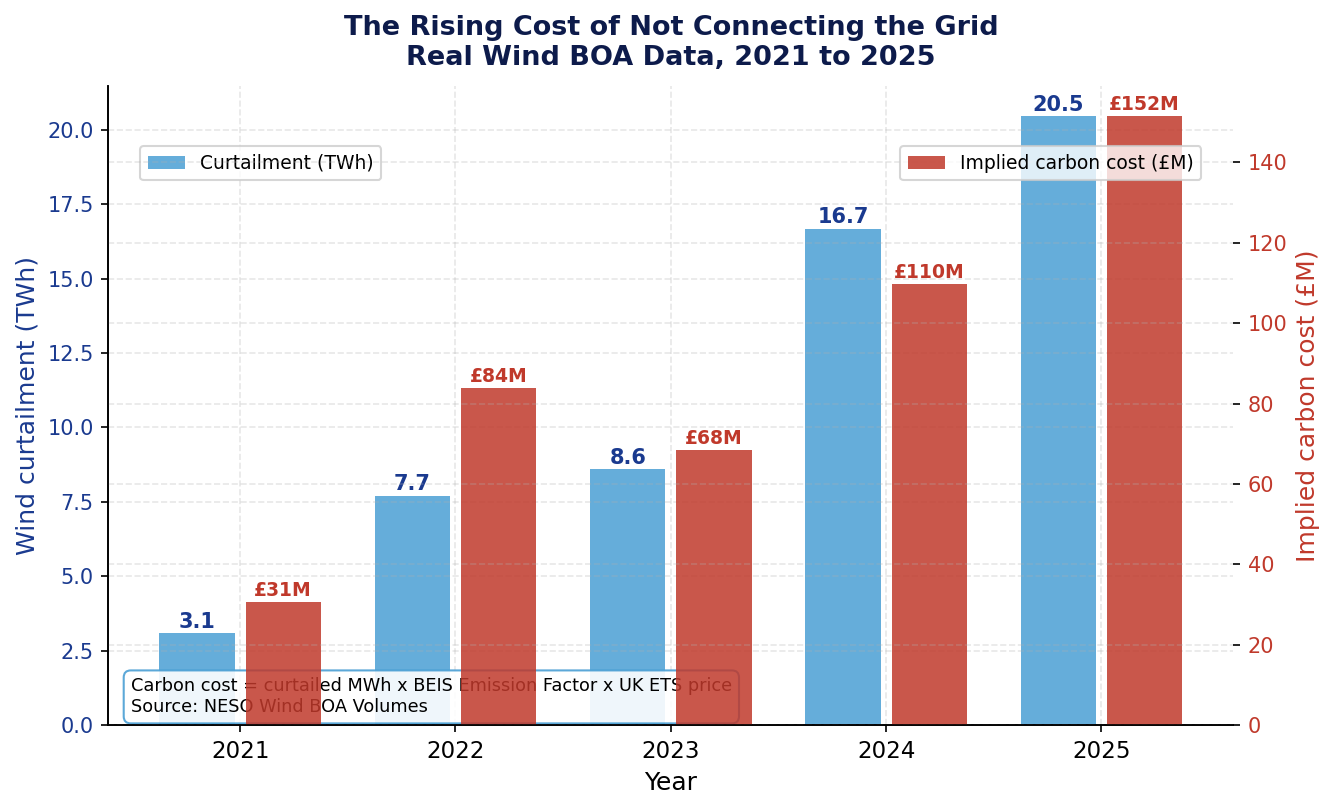

In [11]:
# CELL 11: Figure 4 - Curtailment and carbon cost (real BOA data)

fig, ax1 = plt.subplots(figsize=(9, 5.5))
ax2 = ax1.twinx()

x_pos = np.arange(len(cf))
bars1 = ax1.bar(x_pos - 0.2, cf['Curtailment (GWh)'] / 1000,
                width=0.35, color=ACCENT, alpha=0.85)
bars2 = ax2.bar(x_pos + 0.2, cf['Carbon cost (£M)'],
                width=0.35, color=RED, alpha=0.85)

for bar, val in zip(bars1, cf['Curtailment (GWh)']):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.05,
             f'{val/1000:.1f}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold', color=BLUE)

for bar, val in zip(bars2, cf['Carbon cost (£M)']):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'£{val:.0f}M',
             ha='center', va='bottom',
             fontsize=9, fontweight='bold', color=RED)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(cf['Year'], fontsize=11)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Wind curtailment (TWh)', fontsize=12, color=BLUE)
ax2.set_ylabel('Implied carbon cost (£M)', fontsize=12, color=RED)
ax1.set_title('The Rising Cost of Not Connecting the Grid\nReal Wind BOA Data, 2021 to 2025',
              fontsize=13, fontweight='bold', color=NAVY, pad=10)

ax1.tick_params(axis='y', labelcolor=BLUE)
ax2.tick_params(axis='y', labelcolor=RED)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Method note bottom left, legends separated
ax1.text(0.02, 0.02,
         'Carbon cost = curtailed MWh x BEIS Emission Factor x UK ETS price\nSource: NESO Wind BOA Volumes',
         transform=ax1.transAxes, fontsize=8.5,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=ACCENT, alpha=0.9))

ax1.legend([bars1], ['Curtailment (TWh)'],
           fontsize=9, framealpha=0.8, loc='upper left',
           bbox_to_anchor=(0.02, 0.92))
ax2.legend([bars2], ['Implied carbon cost (£M)'],
           fontsize=9, framealpha=0.8, loc='upper right',
           bbox_to_anchor=(0.98, 0.92))

plt.tight_layout()
plt.savefig('fig4_curtailment_carbon.png')
plt.show()

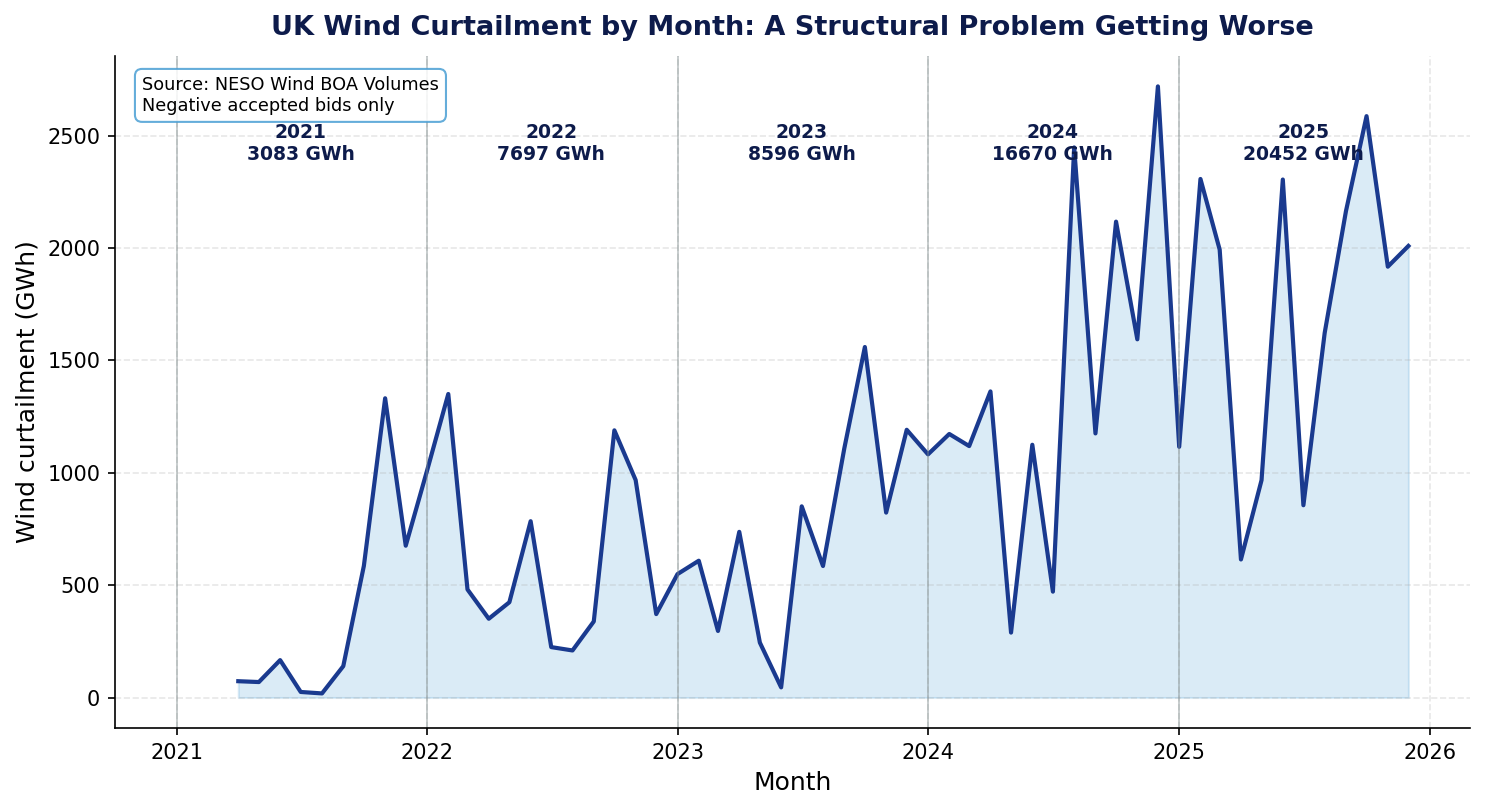

In [12]:
# CELL 12: Figure 5 - Monthly curtailment trend

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.fill_between(monthly_curt['MONTH_DT'], monthly_curt['curtailed_gwh'],
                alpha=0.2, color=ACCENT)
ax.plot(monthly_curt['MONTH_DT'], monthly_curt['curtailed_gwh'],
        color=BLUE, lw=2)

peak = monthly_curt['curtailed_gwh'].max()
for yr in annual_curt['YEAR']:
    val = annual_curt.loc[annual_curt['YEAR'] == yr, 'curtailed_gwh'].values[0]
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color=GRAY, lw=0.8, alpha=0.5)
    ax.text(pd.Timestamp(f'{yr}-07-01'), peak * 0.88,
            f'{yr}\n{val:.0f} GWh',
            ha='center', fontsize=9, color=NAVY, fontweight='bold')

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Wind curtailment (GWh)', fontsize=12)
ax.set_title('UK Wind Curtailment by Month: A Structural Problem Getting Worse',
             fontsize=13, fontweight='bold', color=NAVY, pad=10)

ax.text(0.02, 0.97,
        'Source: NESO Wind BOA Volumes\nNegative accepted bids only',
        transform=ax.transAxes, fontsize=8.5, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=ACCENT, alpha=0.85))

plt.tight_layout()
plt.savefig('fig5_monthly_curtailment.png')
plt.show()

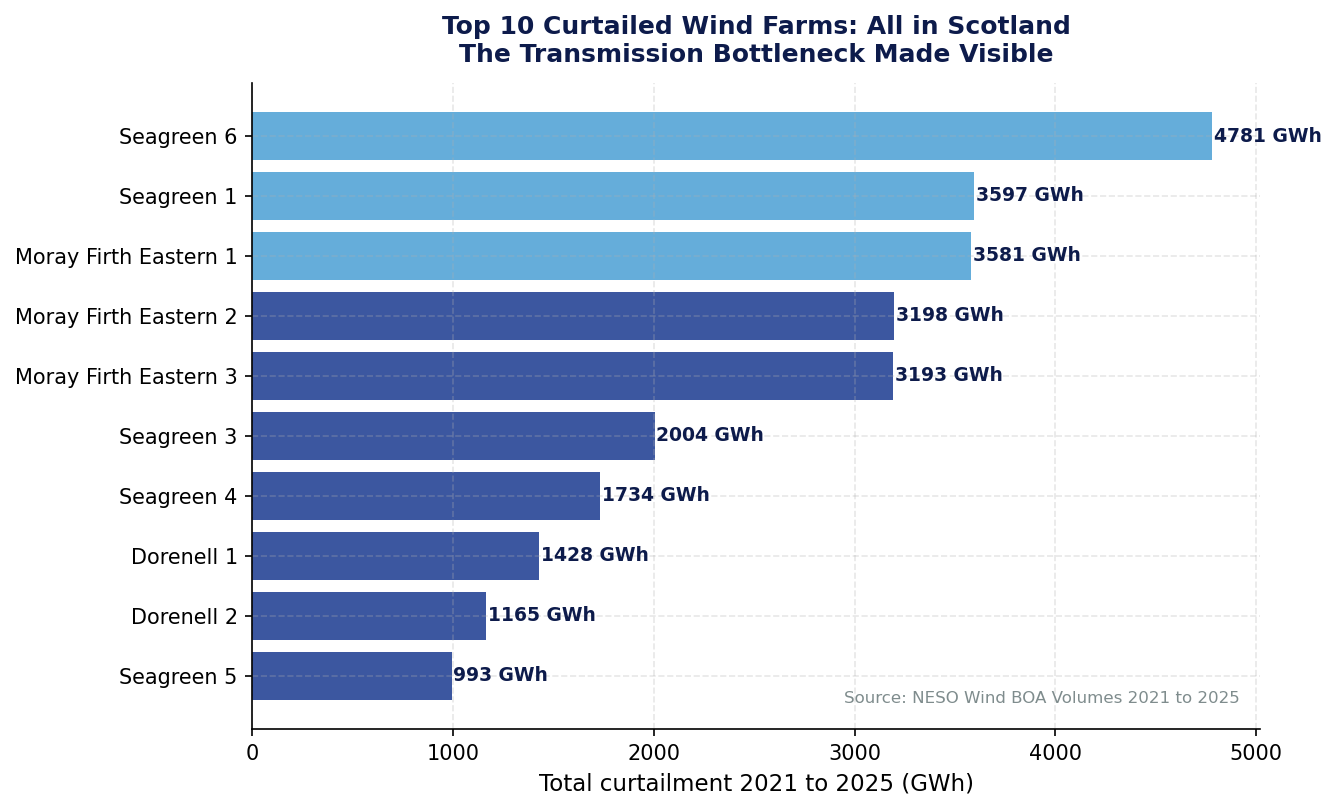

In [13]:
# CELL 13: Figure 6 - Top 10 curtailed wind farms

fig, ax = plt.subplots(figsize=(9, 5.5))

bar_colours = [ACCENT if i < 3 else BLUE for i in range(len(top_farms))]
bars = ax.barh(top_farms['Generator_Full_Name'][::-1],
               top_farms['total_gwh'][::-1],
               color=bar_colours[::-1], alpha=0.85)

for bar, val in zip(bars, top_farms['total_gwh'][::-1]):
    ax.text(bar.get_width() + 8,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.0f} GWh',
            va='center', fontsize=9, fontweight='bold', color=NAVY)

ax.set_xlabel('Total curtailment 2021 to 2025 (GWh)', fontsize=11)
ax.set_title('Top 10 Curtailed Wind Farms: All in Scotland\nThe Transmission Bottleneck Made Visible',
             fontsize=12, fontweight='bold', color=NAVY, pad=10)

ax.text(0.98, 0.04, 'Source: NESO Wind BOA Volumes 2021 to 2025',
        transform=ax.transAxes, fontsize=8, ha='right', color=GRAY)

plt.tight_layout()
plt.savefig('fig6_top_farms.png')
plt.show()

In [14]:
# CELL 14: Summary printout

print("KEY NUMBERS FROM PRIMARY DATA")
print()
print(f"OLS: {slope:.0f} MW gas reduction per 1% renewable share")
print(f"R2 = {r2:.3f}  |  p < 0.001")
print()
for _, row in annual_gen.iterrows():
    print(f"  {int(row['YEAR'])}: renewable={row['avg_renewable_pct']:.1f}%  "
          f"gas={row['avg_gas_mw']/1000:.2f} GW  "
          f"carbon={row['avg_carbon_int']:.0f} gCO2/kWh")
print()
for _, row in cf.iterrows():
    print(f"  {int(row['Year'])}: {row['Curtailment (GWh)']:,.0f} GWh curtailed  "
          f"carbon cost: £{row['Carbon cost (£M)']:.0f}M")
print()
print(f"  Total curtailment 2021 to 2025 : {cf['Curtailment (GWh)'].sum():,.0f} GWh")
print(f"  Total carbon cost 2021 to 2025 : £{cf['Carbon cost (£M)'].sum():,.0f}M")
print(f"  Top curtailed farm             : {top_farms.iloc[0]['Generator_Full_Name']} "
      f"({top_farms.iloc[0]['total_gwh']:.0f} GWh)")

KEY NUMBERS FROM PRIMARY DATA

OLS: -268 MW gas reduction per 1% renewable share
R2 = 0.595  |  p < 0.001

  2021: renewable=27.5%  gas=12.25 GW  carbon=183 gCO2/kWh
  2022: renewable=32.9%  gas=12.70 GW  carbon=181 gCO2/kWh
  2023: renewable=35.2%  gas=9.90 GW  carbon=149 gCO2/kWh
  2024: renewable=36.0%  gas=8.27 GW  carbon=124 gCO2/kWh
  2025: renewable=37.4%  gas=8.82 GW  carbon=127 gCO2/kWh
  2026: renewable=41.8%  gas=9.54 GW  carbon=134 gCO2/kWh

  2021: 3,083 GWh curtailed  carbon cost: £31M
  2022: 7,697 GWh curtailed  carbon cost: £84M
  2023: 8,596 GWh curtailed  carbon cost: £68M
  2024: 16,670 GWh curtailed  carbon cost: £110M
  2025: 20,452 GWh curtailed  carbon cost: £152M

  Total curtailment 2021 to 2025 : 56,498 GWh
  Total carbon cost 2021 to 2025 : £444M
  Top curtailed farm             : Seagreen 6 (4781 GWh)


In [15]:
import os
print(os.getcwd())

C:\Users\kshit\ElectricityGrid
